In [ ]:
# ============================================================
# 03_model_training.py
# Speaker-Level Role Classification
# Compatible with XGBoost 2.x
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
import joblib
import json

# -------------------- Config --------------------
INPUT_PATH = "data/features.csv"

MODEL_DIR = Path("models")
REPORT_DIR = Path("reports")

MODEL_OUTPUT = MODEL_DIR / "role_classifier.pkl"
LABEL_ENCODER_OUTPUT = MODEL_DIR / "label_encoder.pkl"
METRICS_OUTPUT = REPORT_DIR / "eval_metrics.json"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- Load Data --------------------
df = pd.read_csv(INPUT_PATH)
print(f"✅ Loaded {len(df)} speaker-level samples")
print(f"Unique meetings: {df['meeting_id'].nunique()}")

required_cols = {"meeting_id", "speaker_id", "role"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# -------------------- Feature / Target Split --------------------
META_COLS = ["meeting_id", "speaker_id", "role"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
TARGET_COL = "role"

X_all = (
    df[FEATURE_COLS]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

# -------------------- Label Encoding --------------------
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df[TARGET_COL].astype(str))

joblib.dump(label_encoder, LABEL_ENCODER_OUTPUT)
print(f"🎯 Classes: {list(label_encoder.classes_)}")

# -------------------- Meeting-aware split --------------------
meetings = df["meeting_id"].unique()
np.random.seed(42)
np.random.shuffle(meetings)

n_meetings = len(meetings)
n_train = max(int(0.7 * n_meetings), 1)
n_val = max(int(0.15 * n_meetings), 1) if n_meetings >= 3 else 0

train_meetings = meetings[:n_train]
val_meetings = meetings[n_train:n_train + n_val]
test_meetings = meetings[n_train + n_val:]

def split_by_meeting(df_local, meeting_ids):
    return df_local[df_local["meeting_id"].isin(meeting_ids)]

train_df = split_by_meeting(df, train_meetings)
val_df = split_by_meeting(df, val_meetings)
test_df = split_by_meeting(df, test_meetings)

use_cv = False
if len(val_df) == 0 or len(test_df) == 0:
    print("⚠️ Empty val/test split → switching to GroupKFold CV")
    use_cv = True
else:
    X_train = train_df[FEATURE_COLS]
    y_train = label_encoder.transform(train_df[TARGET_COL])
    X_val = val_df[FEATURE_COLS]
    y_val = label_encoder.transform(val_df[TARGET_COL])
    X_test = test_df[FEATURE_COLS]
    y_test = label_encoder.transform(test_df[TARGET_COL])

    print(f"Split → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# -------------------- Class Weights --------------------
def compute_sample_weights(y_encoded):
    classes = np.unique(y_encoded)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_encoded
    )
    weight_map = {cls: w for cls, w in zip(classes, weights)}
    return np.array([weight_map[y] for y in y_encoded])

# -------------------- Model Config --------------------
model_params = dict(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    max_depth=5,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False,
    early_stopping_rounds=30
)

# ============================================================
# TRAINING
# ============================================================
if not use_cv:

    print("🚀 Training XGBoost")

    model = XGBClassifier(**model_params)
    sw_train = compute_sample_weights(y_train)

    model.fit(
        X_train, y_train,
        sample_weight=sw_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # -------------------- Evaluation --------------------
    y_pred = model.predict(X_test)

    y_test_dec = label_encoder.inverse_transform(y_test)
    y_pred_dec = label_encoder.inverse_transform(y_pred)

    print("\n📊 Classification Report:")
    print(classification_report(y_test_dec, y_pred_dec))

    macro_f1 = f1_score(y_test_dec, y_pred_dec, average="macro")

    metrics = {
        "macro_f1": float(macro_f1),
        "train_samples": int(len(train_df)),
        "val_samples": int(len(val_df)),
        "test_samples": int(len(test_df)),
        "labels": list(label_encoder.classes_)
    }
        
    joblib.dump(model, MODEL_OUTPUT)
    print(f"\n✅ Model saved → {MODEL_OUTPUT}")

else:
    # -------------------- GroupKFold CV --------------------
    print("🔁 Running GroupKFold CV (5 folds)")

    groups = df["meeting_id"]
    gkf = GroupKFold(n_splits=5)

    fold_macro_f1 = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, groups), start=1):
        X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]

        sw = compute_sample_weights(y_tr)

        model = XGBClassifier(**model_params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sw,
            eval_set=[(X_te, y_te)],
            verbose=False
        )

        y_pred = model.predict(X_te)
        y_te_dec = label_encoder.inverse_transform(y_te)
        y_pred_dec = label_encoder.inverse_transform(y_pred)

        macro = f1_score(y_te_dec, y_pred_dec, average="macro")
        fold_macro_f1.append(macro)

        print(f"Fold {fold} macro F1: {macro:.3f}")

    metrics = {
        "cv_macro_f1_mean": float(np.mean(fold_macro_f1)),
        "cv_macro_f1_std": float(np.std(fold_macro_f1)),
        "labels": list(label_encoder.classes_)
    }

# -------------------- Save Metrics --------------------
with open(METRICS_OUTPUT, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n📊 Final Metrics:")
print(json.dumps(metrics, indent=2))

# ============================================================
# Optional: Logical Constraint (1 Leader Per Meeting)
# ============================================================

print("\n🧠 Applying optional leader constraint...")

probs = model.predict_proba(X_test)
leader_index = label_encoder.transform(["manager"])[0]

test_results = test_df.copy()
test_results["leader_prob"] = probs[:, leader_index]
test_results["pred"] = y_pred_dec

for meeting in test_results["meeting_id"].unique():
    mask = test_results["meeting_id"] == meeting
    idx = test_results[mask]["leader_prob"].idxmax()
    test_results.loc[idx, "pred"] = "manager"

macro_f1_constrained = f1_score(
    test_results[TARGET_COL],
    test_results["pred"],
    average="macro"
)

print(f"\n🎯 Macro F1 after leader constraint: {macro_f1_constrained:.3f}")


✅ Loaded 1146 speaker-level samples
Unique meetings: 310
🎯 Classes: ['hr', 'junior', 'manager', 'other']
Split → Train: 798, Val: 176, Test: 172
🚀 Training XGBoost


/Users/denuwanwijesinghe/Documents/BSc. Artficial Intellligence/se_project/.venv/lib/python3.14/site-packages/xgboost/callback.py:386: UserWarning: [12:42:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



📊 Classification Report:
              precision    recall  f1-score   support

          hr       0.36      0.33      0.35        12
      junior       0.66      0.57      0.61        37
     manager       0.61      0.51      0.55        45
       other       0.70      0.82      0.76        78

    accuracy                           0.65       172
   macro avg       0.58      0.56      0.57       172
weighted avg       0.64      0.65      0.64       172


✅ Model saved → models/role_classifier.pkl

📊 Final Metrics:
{
  "macro_f1": 0.567033764076114,
  "train_samples": 798,
  "val_samples": 176,
  "test_samples": 172,
  "labels": [
    "hr",
    "junior",
    "manager",
    "other"
  ]
}

🧠 Applying optional leader constraint...

🎯 Macro F1 after leader constraint: 0.537


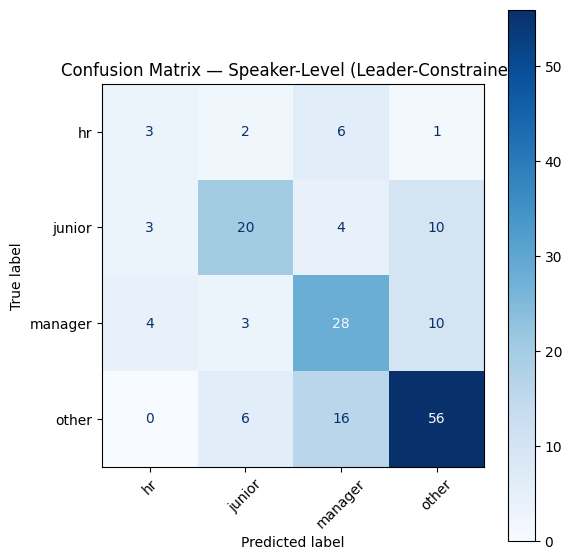

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = list(label_encoder.classes_)

cm = confusion_matrix(
    test_results["role"],   # true labels
    test_results["pred"],   # constrained predictions
    labels=labels
)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d")

plt.title("Confusion Matrix — Speaker-Level (Leader-Constrained)")
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd

# --------------------------------------------------
# 0) Safety check
# --------------------------------------------------
if "test_df" not in globals():
    raise RuntimeError(
        "❌ test_df not found. "
        "Speaker-level error analysis requires single split training."
    )

# --------------------------------------------------
# 1) Attach predictions to speaker-level test set
# --------------------------------------------------
test_with_preds = test_df.copy()
test_with_preds["y_true"] = y_test_dec
test_with_preds["y_pred"] = y_pred_dec

# --------------------------------------------------
# 2) Filter misclassified speakers
# --------------------------------------------------
errors = test_with_preds[
    test_with_preds["y_true"] != test_with_preds["y_pred"]
].copy()

print(f"❗ Found {len(errors)} misclassified speakers out of {len(test_df)} test samples")

# --------------------------------------------------
# 3) Inspect error examples
# --------------------------------------------------
errors_view = errors[[
    "meeting_id",
    "speaker_id",
    "word_count",
    "word_count_share",
    "directive_count",
    "directive_share",
    "uncertainty_count",
    "turn_count",
    "turn_share",
    "y_true",
    "y_pred"
]].head(10)

errors_view


❗ Found 60 misclassified speakers out of 172 test samples


,meeting_id,speaker_id,word_count,word_count_share,directive_count,directive_share,uncertainty_count,turn_count,turn_share,y_true,y_pred
82,scrum_021,spk_3,24,0.282353,0,0.0,0,1,0.250000,junior,other
200,scrum_051,spk_1,13,0.260000,0,0.0,0,1,0.250000,manager,other
210,scrum_053,spk_3,9,0.257143,0,0.0,0,1,0.250000,junior,other
322,scrum_088,spk_1,17,0.377778,0,0.0,1,1,0.333333,junior,other
324,scrum_088,spk_3,14,0.311111,0,0.0,1,1,0.333333,other,junior
326,scrum_089,spk_2,12,0.342857,0,0.0,1,1,0.333333,other,junior
327,scrum_089,spk_3,11,0.314286,0,0.0,0,1,0.333333,manager,other
381,scrum_107,spk_2,18,0.428571,0,0.0,0,1,0.333333,manager,other
431,scrum_122,spk_2,8,0.347826,0,0.0,0,1,0.333333,other,manager
455,scrum_131,spk_1,8,0.307692,0,0.0,0,1,0.333333,manager,other


In [13]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1) Extract feature importances safely
# --------------------------------------------------
fi = model.feature_importances_

if len(fi) != len(FEATURE_COLS):
    raise ValueError(
        f"Feature importance length mismatch: "
        f"{len(fi)} importances vs {len(FEATURE_COLS)} feature names"
    )

fi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": fi
})

# --------------------------------------------------
# 2) Sort features
# --------------------------------------------------
fi_df_sorted = fi_df.sort_values("importance", ascending=False)

print("🔝 Top 30 Most Important Features (Speaker-Level):")
display(fi_df_sorted.head(30))

# --------------------------------------------------
# 3) Separate structural vs TF-IDF features
# --------------------------------------------------

structural_feats = fi_df_sorted[
    ~fi_df_sorted["feature"].str.startswith("tfidf_")
]

tfidf_feats = fi_df_sorted[
    fi_df_sorted["feature"].str.startswith("tfidf_")
]

print("\n🧠 Top Structural Features:")
display(structural_feats.head(15))

print("\n📚 Top TF-IDF Features:")
display(tfidf_feats.head(15))


🔝 Top 30 Most Important Features (Speaker-Level):


,feature,importance
6,uncertainty_count,0.133181
11,turn_share,0.057938
1,avg_sentence_len,0.045319
2,question_count,0.041566
13,tfidf_1,0.032724
16,tfidf_4,0.032686
15,tfidf_3,0.030421
18,tfidf_6,0.028427
9,word_count_share,0.028269
14,tfidf_2,0.028257



🧠 Top Structural Features:


,feature,importance
6,uncertainty_count,0.133181
11,turn_share,0.057938
1,avg_sentence_len,0.045319
2,question_count,0.041566
9,word_count_share,0.028269
4,soft_help_count,0.020394
0,word_count,0.019432
5,directive_count,0.019151
3,hard_directive_count,0.016690
8,sentiment_score,0.014639



📚 Top TF-IDF Features:


,feature,importance
13,tfidf_1,0.032724
16,tfidf_4,0.032686
15,tfidf_3,0.030421
18,tfidf_6,0.028427
14,tfidf_2,0.028257
12,tfidf_0,0.024601
23,tfidf_11,0.024482
37,tfidf_25,0.022781
34,tfidf_22,0.022342
17,tfidf_5,0.020241


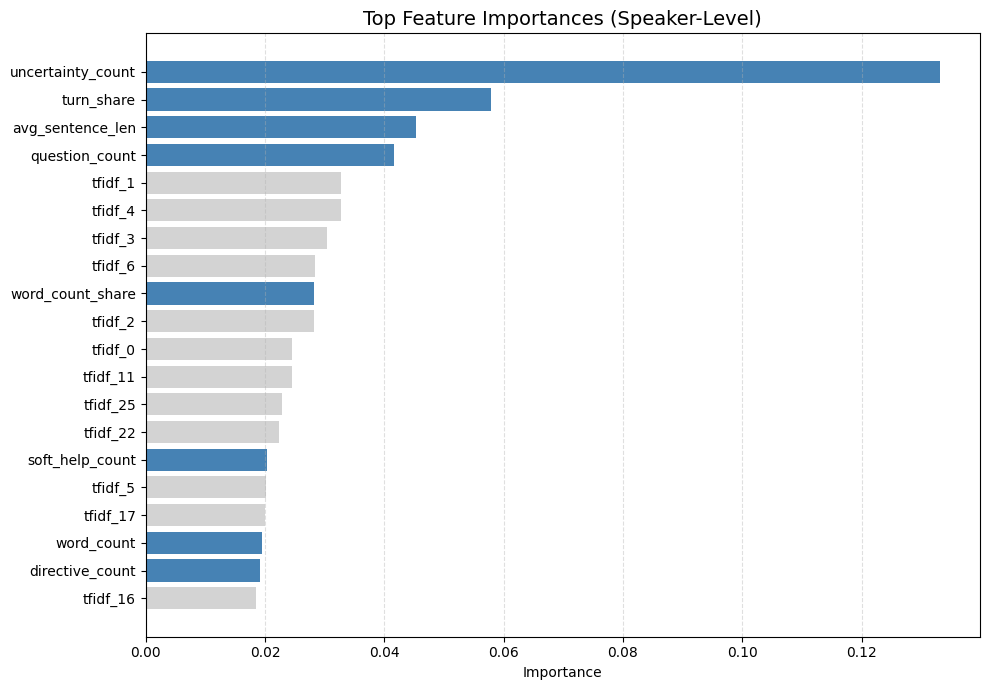

In [14]:
import matplotlib.pyplot as plt

top_n = 20
top_feats = fi_df_sorted.head(top_n)[::-1]

# Identify structural vs tfidf
colors = [
    "steelblue" if not f.startswith("tfidf_") else "lightgray"
    for f in top_feats["feature"]
]

plt.figure(figsize=(10, 7))
plt.barh(top_feats["feature"], top_feats["importance"], color=colors)

plt.title("Top Feature Importances (Speaker-Level)", fontsize=14)
plt.xlabel("Importance")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


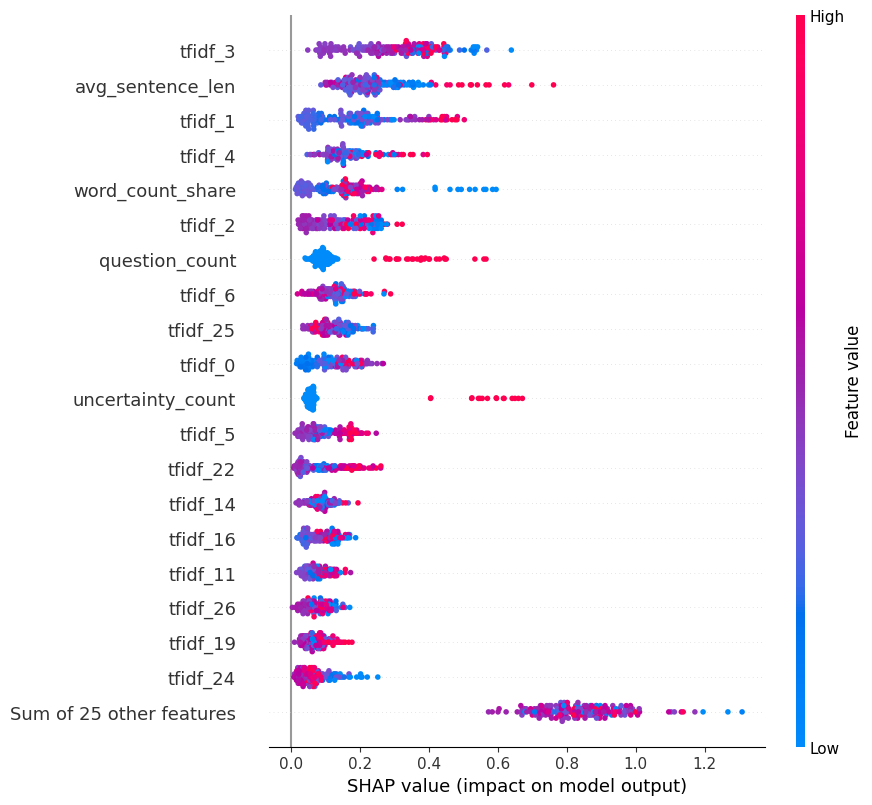

In [15]:
import shap
import numpy as np

# --------------------------------------------------
# 1) Align test features
# --------------------------------------------------
X_test_aligned = X_test[FEATURE_COLS]

# --------------------------------------------------
# 2) Use TreeExplainer (better for XGBoost)
# --------------------------------------------------
explainer = shap.TreeExplainer(model)

# shap_values will be list of arrays (one per class)
shap_values = explainer.shap_values(X_test_aligned)

# --------------------------------------------------
# 3) Aggregate absolute SHAP values across classes
# --------------------------------------------------
# Convert list → array if multi-class
if isinstance(shap_values, list):
    shap_values = np.stack(shap_values, axis=2)

# shape: (n_samples, n_features, n_classes)
shap_values_global = np.mean(
    np.abs(shap_values),
    axis=2
)

# --------------------------------------------------
# 4) Create SHAP Explanation object
# --------------------------------------------------
shap_exp_global = shap.Explanation(
    values=shap_values_global,
    data=X_test_aligned.values,
    feature_names=FEATURE_COLS
)

# --------------------------------------------------
# 5) Global Beeswarm Plot
# --------------------------------------------------
shap.plots.beeswarm(
    shap_exp_global,
    max_display=20
)
